<a href="https://colab.research.google.com/github/carterliston013/DCS-110/blob/main/Data_Visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This line of code imports the pandas library as 'pd' and the matploylib pyplot module as 'plt'. These are used to help us manipulate our data and create visual aids to help showcase trends and data in ways that may not be as accessible with the data alone.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

This command establishes the dataframe as the data that we are importing from an external source. It uses pd.read_csv to open and read the data to input it into the Python code format.

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/osoliman/DSC110/refs/heads/main/Datasets/nhanes_final.csv')

This command shows the first 5 rows in the dataframe that we have established using the 'head' command.

In [3]:
df.head()

,id,gender,age,race_ethnicity,education,bmi,height_cm,systolic_bp,has_diabetes,hba1c,fasting_glucose
0,130378.0,1.0,43.0,6.0,5.0,27.0,179.5,135.0,2.0,5.6,113.0
1,130379.0,1.0,66.0,3.0,5.0,33.5,174.2,121.0,2.0,5.6,99.0
2,130380.0,2.0,44.0,2.0,3.0,29.7,152.9,111.0,1.0,6.2,156.0
3,130381.0,2.0,5.0,7.0,NaN,23.8,120.1,NaN,2.0,NaN,NaN
4,130382.0,1.0,2.0,3.0,NaN,NaN,NaN,NaN,2.0,NaN,NaN


One Numerical Variable

This command creates a histogram (using 'hist') to describe the data in the bmi field of the established dataframe. A histogram is used for continuous data and can be customized to fit the data in the most accurate and understandable way.

<Axes: >

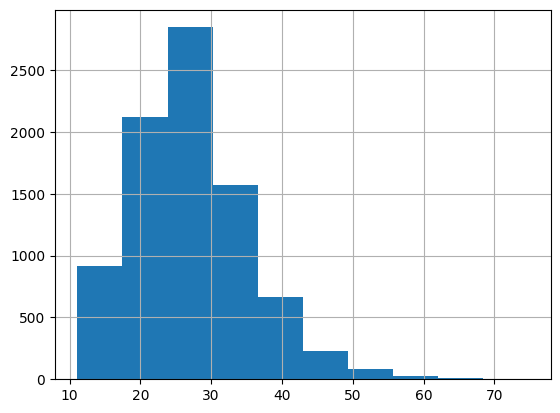

In [4]:
df['bmi'].hist()

One Categorical Variable

This command creates a bar chart for the data in the gender field of the established dataframe using 'plot' and 'kind='bar''. It uses the value_counts command because it is a categorical variable and thus can count how many of each input there are.

<Axes: xlabel='gender'>

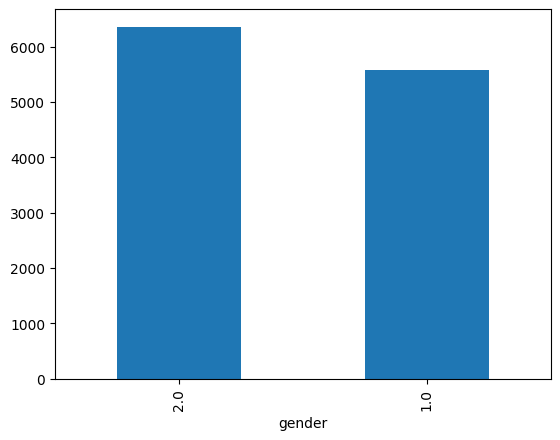

In [5]:
df['gender'].value_counts().plot(kind='bar')

Two Numerical Variables

This command creates a scatter plot, defining the x and y axes as 'fasting_glucose' and 'hba1c' respectively. Scatterplots are useful for two continuous variables because they compare the relationship between the two variables well and offer the trend that this relationship might have.

<Axes: xlabel='fasting_glucose', ylabel='hba1c'>

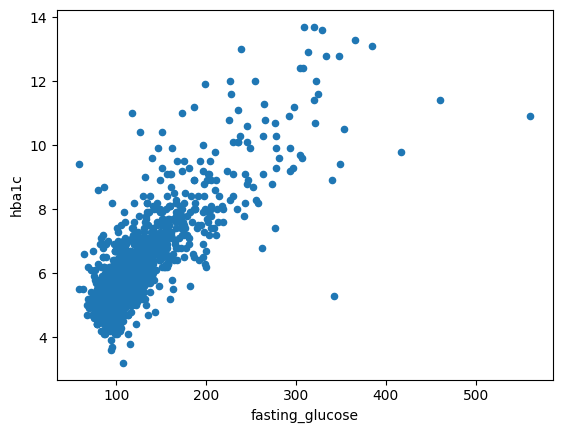

In [7]:
df.plot(x = 'fasting_glucose', y = 'hba1c', kind = 'scatter')

Two Categorical Variables

This uses the crosstab command to show the relationship between two categorical variables using a bar chart. This chart shows the relationship between gender and having diabetes using the crosstab function.

<Axes: xlabel='gender'>

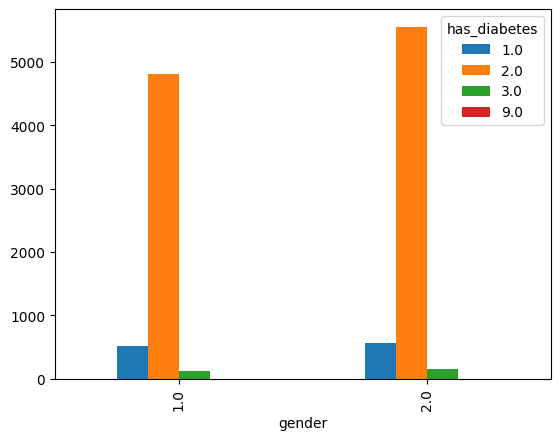

In [10]:
pd.crosstab(df['gender'], df['has_diabetes']).plot(kind='bar')

One Numerical and One Categorical

This command creates a boxplot, making the column of data 'bmi' and grouping them by which gender they are. Boxplots are very helpful when numerical data is needed to be grouped by data that is categorical in nature because it allows several plots to be drawn for different categorical variables.

<Axes: title={'center': 'bmi'}, xlabel='gender'>

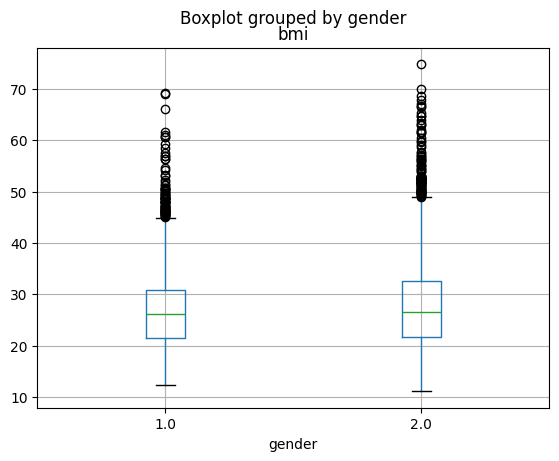

In [11]:
df.boxplot(column='bmi', by='gender')

**More Professionalism**

One Numerical

This is the histogram revisited with more detail and professionalism. The color and edge color are changed to 'hotpink' and 'lightblue' respectively as it helps created contrast and easier visibility between segments. I changed the 'bins' parameter to 40 to more accuratel show the trend of data and where it actually falls along the age distribution. We also used the commands 'plt.title', 'plt.xlabel', and 'plt.ylabel' to label the graph on the axes and the title to give more information to the one reading the histogram. Finally, we turned off the grid that overlays the graph by using the command 'plt.grid(False)'.

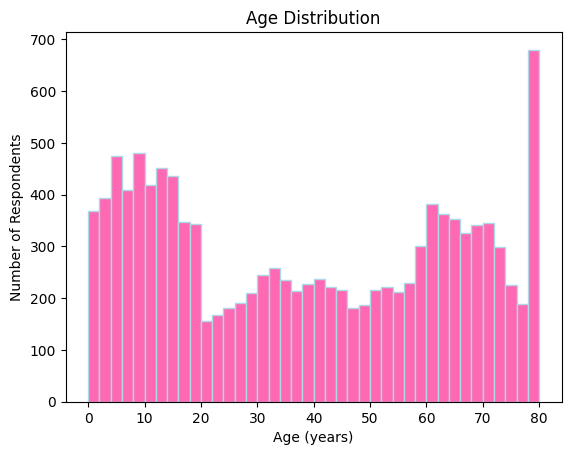

In [29]:
df['age'].hist(color = 'hotpink', edgecolor = 'lightblue', bins = 40)
plt.title('Age Distribution')
plt.xlabel('Age (years)')
plt.ylabel('Number of Respondents')
plt.grid(False)

# Seaborn Library

This command imports the seaborn library to Python as 'sns', similarly to how we added the original libraries. This would normally be included in the beginning of coding, but since we are learning we add the libraries as we go. Seaborn allows us to add more descriptive visuals and gives us more freedom in how we describe data.

In [30]:
import seaborn as sns

Violin Plot

These first two commands establish a filter to only include yes and no answers to whether or not someone has diabetes in our data by using the 'isin([1,2])' section of the code, and we create a copy. The second command created the map for these two variables and establishes the map using the 'has_diabetes' field from the originally established data frame.

The next portion of code is used to create a Violin plot, used to show distribution curves for a continuous variable on the basis of categorical variables. In this we used commands (previously used in our histogram customization) to establish the axes and title, as well as labelling and coloring the plot for clarity and understanding.

Text(0, 0.5, 'BMI (kg/m²)')

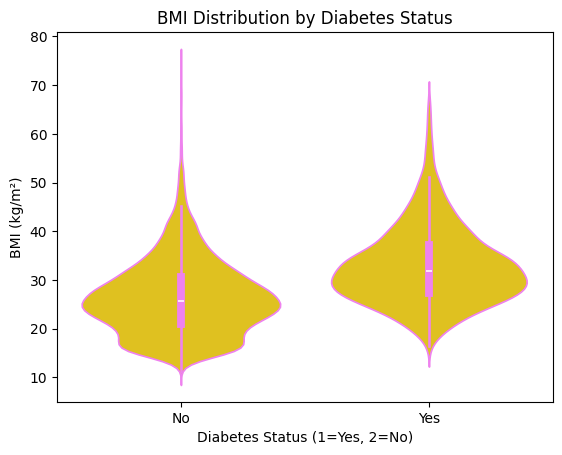

In [40]:
# Filter to only Yes (1) and No (2) diabetes responses
df_diabetes = df[df['has_diabetes'].isin([1, 2])].copy()

diabetes_map={1:'Yes', 2:'No'}
df_diabetes['has_diabetes']=df_diabetes['has_diabetes'].map(diabetes_map)

# Create violin plot
sns.violinplot(data=df_diabetes, x='has_diabetes', y='bmi', color='gold', edgecolor='violet')
plt.title('BMI Distribution by Diabetes Status')
plt.xlabel('Diabetes Status (1=Yes, 2=No)')
plt.ylabel('BMI (kg/m²)')


Heatmap

This first command described the numeric columns in the data frame, including age, bmi, systolic blood pressure, hba1c, and fasting glucose, creating a correlation function for them using the 'corr()' command.

The second of the commands uses the Seaborn library to create a heatmap. We include the numeric columns, the 'annot=True' command to show the numerical values in the cells of the heatmap, the color palette of the heatmap using 'cmap='Pastel1'', and 'center=0' to establish the center as 0.

Text(0.5, 1.0, 'Correlation Between Numeric Variables')

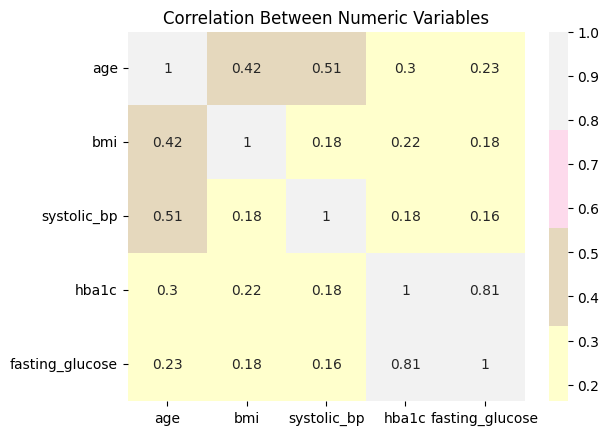

In [46]:
numeric_cols = df[['age', 'bmi', 'systolic_bp', 'hba1c', 'fasting_glucose']].corr()

sns.heatmap(numeric_cols, annot=True, cmap='Pastel1', center=0)
plt.title('Correlation Between Numeric Variables')

This was the function we wrote in class to explain how one would create the table one data we read in the journal we read as a group. This puts out the mean and standard deviation for age from our original dataframe.

In [59]:
print(df['age'].mean()),
print('±',(df['age'].std()))

38.317858040727394
± 25.60199011389104


New Package/Library


Table One

This command installs the tableone package to allow new commands and data to be manipulated for the specific use in table ones.

In [60]:
pip install tableone

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.6 MB/s eta 0:00:00


This command imports the table one library/dataset to Python.

In [61]:
import tableone

This command outputs and displays table one as we have just installed and imported using the dataframe we have previously established.

In [62]:
tableone.TableOne(df)

Missing            Overall
n                                                    11933
id, mean (SD)                         0  136344.0 (3444.9)
gender, n (%)              1.0                 5575 (46.7)
                           2.0                 6358 (53.3)
age, mean (SD)                        0        38.3 (25.6)
race_ethnicity, n (%)      1.0                  1117 (9.4)
                           2.0                 1373 (11.5)
                           3.0                 6217 (52.1)
                           4.0                 1597 (13.4)
                           6.0                   681 (5.7)
                           7.0                   948 (7.9)
education, n (%)           1.0                   373 (3.1)
                           2.0                   666 (5.6)
                           3.0                 1749 (14.7)
                           4.0                 2370 (19.9)
                           5.0                 2625 (22.0)
                           9.0                    11 (0.1)
                           None                4139 (34.7)
bmi, mean (SD)                     3462         27.2 (8.1)
height_cm, mean (SD)               3434       159.7 (19.9)
systolic_bp, mean (SD)             4416       119.3 (18.6)
has_diabetes, n (%)        1.0                  1081 (9.1)
                           2.0                10371 (86.9)
                           3.0                   284 (2.4)
                           9.0                     4 (0.0)
                           None                  193 (1.6)
hba1c, mean (SD)                   5218          5.7 (1.1)
fasting_glucose, mean (SD)         8261       107.9 (32.5)

This command, 'show_histograms=True' shows the histograms that can be created from the continous variable data in the table one we have created using the established dataframe.

In [63]:
tableone.TableOne(df, show_histograms=True)

Missing            Overall Histogram
n                                                    11933          
id, mean (SD)                         0  136344.0 (3444.9)  █▇▇▇▇▇▇█
gender, n (%)              1.0                 5575 (46.7)          
                           2.0                 6358 (53.3)          
age, mean (SD)                        0        38.3 (25.6)  █▇▃▄▄▄▆▆
race_ethnicity, n (%)      1.0                  1117 (9.4)          
                           2.0                 1373 (11.5)          
                           3.0                 6217 (52.1)          
                           4.0                 1597 (13.4)          
                           6.0                   681 (5.7)          
                           7.0                   948 (7.9)          
education, n (%)           1.0                   373 (3.1)          
                           2.0                   666 (5.6)          
                           3.0                 1749 (14.7)          
                           4.0                 2370 (19.9)          
                           5.0                 2625 (22.0)          
                           9.0                    11 (0.1)          
                           None                4139 (34.7)          
bmi, mean (SD)                     3462         27.2 (8.1)  ▅▆█▆▃▂▁▁
height_cm, mean (SD)               3434       159.7 (19.9)  ▁▁▁▁▃█▇▃
systolic_bp, mean (SD)             4416       119.3 (18.6)  ▃▆█▅▃▂▁▁
has_diabetes, n (%)        1.0                  1081 (9.1)          
                           2.0                10371 (86.9)          
                           3.0                   284 (2.4)          
                           9.0                     4 (0.0)          
                           None                  193 (1.6)          
hba1c, mean (SD)                   5218          5.7 (1.1)  ▄█▂▁▁▁▁▁
fasting_glucose, mean (SD)         8261       107.9 (32.5)  █▅▁▁▁▁▁▁

This is an identical command to the previous line of code except for using the 'nonnormal' function. We used this for age and height in cm in order to group them by the median and first and third quartiles, rather than the mean and standard deviation.

In [66]:
tableone.TableOne(df, show_histograms=True, nonnormal=['age', 'height_cm'])

Missing              Overall Histogram
n                                                      11933          
id, mean (SD)                         0    136344.0 (3444.9)  █▇▇▇▇▇▇█
gender, n (%)              1.0                   5575 (46.7)          
                           2.0                   6358 (53.3)          
age, median [Q1,Q3]                   0     37.0 [13.0,62.0]  █▇▃▄▄▄▆▆
race_ethnicity, n (%)      1.0                    1117 (9.4)          
                           2.0                   1373 (11.5)          
                           3.0                   6217 (52.1)          
                           4.0                   1597 (13.4)          
                           6.0                     681 (5.7)          
                           7.0                     948 (7.9)          
education, n (%)           1.0                     373 (3.1)          
                           2.0                     666 (5.6)          
                           3.0                   1749 (14.7)          
                           4.0                   2370 (19.9)          
                           5.0                   2625 (22.0)          
                           9.0                      11 (0.1)          
                           None                  4139 (34.7)          
bmi, mean (SD)                     3462           27.2 (8.1)  ▅▆█▆▃▂▁▁
height_cm, median [Q1,Q3]          3434  163.6 [154.4,172.1]  ▁▁▁▁▃█▇▃
systolic_bp, mean (SD)             4416         119.3 (18.6)  ▃▆█▅▃▂▁▁
has_diabetes, n (%)        1.0                    1081 (9.1)          
                           2.0                  10371 (86.9)          
                           3.0                     284 (2.4)          
                           9.0                       4 (0.0)          
                           None                    193 (1.6)          
hba1c, mean (SD)                   5218            5.7 (1.1)  ▄█▂▁▁▁▁▁
fasting_glucose, mean (SD)         8261         107.9 (32.5)  █▅▁▁▁▁▁▁